<a href="https://colab.research.google.com/github/Diego-Rodriguez16/mini-robots-2026-II/blob/main/6_Machine_Learning/Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning: ejercicios del capítulo 6

**Idea general:** en programación tradicional uno le da al computador **datos + reglas** y obtiene **respuestas**. En Machine Learning uno le da **datos + respuestas** y el computador encuentra las **reglas** (el modelo).

**Contenido**
1. Multiplicar matrices 2×2: regla escrita a mano vs. red neuronal (ejercicio 1).
2. Tres algoritmos de ML con datos de una entidad del gobierno: **KNN**, **Árbol de decisión** y **SVM**

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

## Ejercicio 1. Multiplicar matrices 2×2 con ML

**Qué pide:** crear un dataset con 50.000 multiplicaciones de matrices 2×2 (números enteros entre -20 y 20), entrenar un modelo, probarlo con 10 ejemplos, compararlo con el cálculo normal y ver **cuál es más costoso**.

**Idea (figura 6.1):**
- *Forma tradicional:* la regla de multiplicar matrices.
- *Forma ML:* no le digo la regla; le doy 50.000 ejemplos (A, B y el resultado C) y que la red la descubra.

### Paso 1. Crear el dataset

In [2]:
np.random.seed(0)
N = 50000
A = np.random.randint(-20, 21, (N, 2, 2))   # 50.000 matrices A
B = np.random.randint(-20, 21, (N, 2, 2))   # 50.000 matrices B
C = A @ B                                   # resultado correcto (rótulo)

print("Ejemplo:")
print("A =\n", A[0])
print("B =\n", B[0])
print("A x B =\n", C[0])

Ejemplo:
A =
 [[-20 -17]
 [-17  19]]
B =
 [[-16   7]
 [  6  10]]
A x B =
 [[ 218 -310]
 [ 386   71]]


**Paso 2. Preparar los datos.** La red recibe 8 números (los 4 de A y los 4 de B) y debe devolver 4 (los de C). Los divido entre 20 y entre 200 para que queden en valores pequeños (la red aprende mejor así). Entreno con 40.000 ejemplos y dejo 10.000 para probar.

In [3]:
X = np.hstack([A.reshape(N, 4), B.reshape(N, 4)]) / 20   # entradas (8)
Y = C.reshape(N, 4) / 200                                # salidas (4)

X_tr, X_te = X[:40000], X[40000:]
Y_tr, Y_te = Y[:40000], Y[40000:]

**Paso 3. Crear y entrenar la red** (tres capas ocultas de 128 neuronas; es un problema de predecir números, por eso la salida no lleva activación).

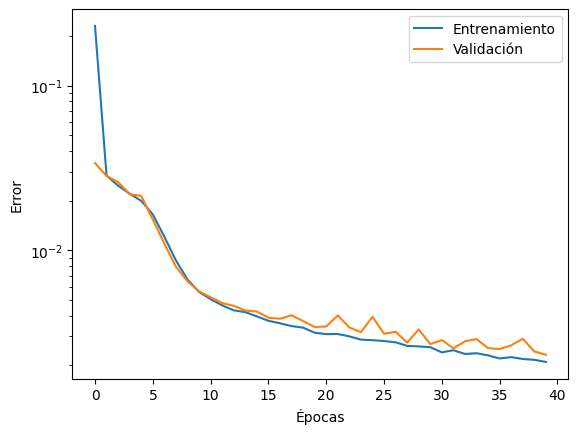

Tiempo de entrenamiento: 38.4 s


In [4]:
modelo = keras.Sequential([
    keras.layers.Input(shape=(8,)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(4)
])
modelo.compile(optimizer="adam", loss="mean_squared_error")

t0 = time.perf_counter()
historia = modelo.fit(X_tr, Y_tr, epochs=40, batch_size=256, validation_split=0.1, verbose=0)
tiempo_entrenar = time.perf_counter() - t0

plt.plot(historia.history["loss"], label="Entrenamiento")
plt.plot(historia.history["val_loss"], label="Validación")
plt.yscale("log"); plt.xlabel("Épocas"); plt.ylabel("Error"); plt.legend(); plt.show()
print("Tiempo de entrenamiento:", round(tiempo_entrenar, 1), "s")

**Paso 4. Probar con 10 ejemplos** que la red nunca vio y comparar con el resultado real (cálculo analítico).

In [5]:
pred = modelo.predict(X_te[:10], verbose=0) * 200
real = C[40000:40010].reshape(10, 4)

tabla = pd.DataFrame({
    "Real (analítico)": [list(r) for r in real],
    "Predicción de la red": [list(np.round(p).astype(int)) for p in pred],
    "Error promedio": np.abs(real - pred).mean(axis=1).round(2)
})
tabla

,Real (analítico),Predicción de la red,Error promedio
0,"[20, 136, -170, -78]","[19, 148, -169, -86]",5.55
1,"[-159, 303, -198, 390]","[-163, 302, -189, 381]",5.83
2,"[116, 16, -428, 12]","[121, 24, -429, 8]",4.37
3,"[-168, -90, 8, 60]","[-161, -93, 16, 61]",4.69
4,"[54, 98, -141, -187]","[63, 109, -140, -186]",5.46
5,"[-34, 289, -308, -118]","[-37, 286, -315, -107]",6.14
6,"[124, -39, 368, 210]","[118, -27, 386, 221]",11.95
7,"[-20, 142, -130, 243]","[-16, 124, -142, 248]",9.68
8,"[-75, -25, -225, -165]","[-77, -11, -225, -156]",6.29
9,"[180, -380, -261, 551]","[182, -369, -257, 546]",5.52


In [6]:
pred_todo = modelo.predict(X_te, verbose=0) * 200
error_medio = np.abs(C[40000:].reshape(-1, 4) - pred_todo).mean()
print("Error promedio en los 10.000 ejemplos de prueba:", round(error_medio, 2), "(los resultados van de -800 a 800)")

Error promedio en los 10.000 ejemplos de prueba: 7.42 (los resultados van de -800 a 800)


**Paso 5. ¿Cuál es más costoso computacionalmente?** Se mide cuánto tarda cada forma en resolver las 10.000 multiplicaciones de prueba.

In [7]:
t0 = time.perf_counter()
_ = A[40000:] @ B[40000:]                       # forma analítica
t_analitico = time.perf_counter() - t0

t0 = time.perf_counter()
_ = modelo.predict(X_te, verbose=0)             # forma con la red
t_red = time.perf_counter() - t0

print(f"Analítico: {t_analitico*1000:.3f} ms")
print(f"Red neuronal (solo predecir): {t_red*1000:.1f} ms")
print(f"Entrenar la red: {tiempo_entrenar:.1f} s")
print("Operaciones por multiplicación -> analítico: 8 productos y 4 sumas (12).")
print("Parámetros de la red (cada uno se usa al predecir):", modelo.count_params())

Analítico: 0.568 ms
Red neuronal (solo predecir): 555.7 ms
Entrenar la red: 38.4 s
Operaciones por multiplicación -> analítico: 8 productos y 4 sumas (12).
Parámetros de la red (cada uno se usa al predecir): 34692


**Conclusión 1:**
- Cálculo analítico: 0.568ms. Red: 555.7ms más 38.4s de entrenamiento. La forma analítica es **mucho más barata** (12 operaciones contra miles).
- Para este problema no conviene usar ML, porque la regla ya se conoce y es simple. ML sirve cuando **no** se conoce la regla o es muy difícil de programar (traducir idiomas, detectar spam, reconocer imágenes), como dice el documento.

## Datos de una entidad del gobierno (para los ejercicios 2, 3 y 4)

**Entidad:** ICFES (Instituto Colombiano para la Evaluación de la Educación), en el portal de datos abiertos de Colombia (`datos.gov.co`). Dataset: *Resultados únicos Saber 11*.

**Problema a resolver:** clasificar si un estudiante tiene un puntaje **alto o bajo en Matemáticas** usando sus puntajes en las otras materias (lectura crítica, ciencias naturales, sociales e inglés).
- **Características (features):** los 4 puntajes de las otras materias.
- **Rótulo:** 1 si el puntaje de matemáticas es mayor o igual a la mediana, 0 si es menor.

Los tres algoritmos usan **el mismo problema y los mismos datos** para poder compararlos.

In [8]:
# Se descargan 5.000 estudiantes del portal de datos abiertos
URL = "https://www.datos.gov.co/resource/kgxf-xxbe.csv?$limit=5000"
datos = pd.read_csv(URL)
print(datos.shape)
datos.head(3)

(5000, 51)


,periodo,estu_tipodocumento,estu_consecutivo,cole_area_ubicacion,cole_bilingue,cole_calendario,cole_caracter,cole_cod_dane_establecimiento,cole_cod_dane_sede,cole_cod_depto_ubicacion,...,fami_tienecomputador,fami_tieneinternet,fami_tienelavadora,desemp_ingles,punt_ingles,punt_matematicas,punt_sociales_ciudadanas,punt_c_naturales,punt_lectura_critica,punt_global
0,20131,CR,SB11201310000414,URBANO,N,B,ACADÉMICO,3.118480e+11,311848000812,11,...,Si,Si,Si,B+,94.0,88.0,NaN,NaN,NaN,NaN
1,20194,TI,SB11201940464873,RURAL,N,A,TÉCNICO/ACADÉMICO,1.410160e+11,241016000342,41,...,Si,Si,Si,B1,71.0,66.0,70.0,65.0,69.0,339.0
2,20194,TI,SB11201940464873,RURAL,N,A,TÉCNICO/ACADÉMICO,1.410160e+11,241016000342,41,...,Si,Si,Si,B1,71.0,66.0,70.0,65.0,69.0,339.0


Columnas de los puntajes (por si el nombre exacto cambia un poco) y quedarse solo con la que se necesitan.

In [9]:
def buscar(texto):
    for c in datos.columns:
        if "punt_" in c.lower() and texto in c.lower():
            return c
    raise ValueError(f"No encontré una columna con '{texto}'. Columnas disponibles: {list(datos.columns)}")

col_mate = buscar("mat")
col_features = [buscar("lectura"), buscar("natur"), buscar("social"), buscar("ingles")]
print("Rótulo (matemáticas):", col_mate)
print("Características:", col_features)

df = datos[[col_mate] + col_features].apply(pd.to_numeric, errors="coerce").dropna()
print("Estudiantes que quedan:", len(df))
df.describe().round(1)

Rótulo (matemáticas): punt_matematicas
Características: ['punt_lectura_critica', 'punt_c_naturales', 'punt_sociales_ciudadanas', 'punt_ingles']
Estudiantes que quedan: 2778


,punt_matematicas,punt_lectura_critica,punt_c_naturales,punt_sociales_ciudadanas,punt_ingles
count,2778.0,2778.0,2778.0,2778.0,2778.0
mean,50.3,51.4,50.0,48.7,49.9
std,11.7,10.2,10.4,11.6,12.3
min,19.0,0.0,20.0,17.0,23.0
25%,42.0,44.0,43.0,40.0,42.0
50%,50.0,51.0,50.0,48.0,49.0
75%,58.0,58.0,57.0,56.0,56.0
max,100.0,100.0,93.0,96.0,100.0


In [10]:
mediana = df[col_mate].median()
y = (df[col_mate] >= mediana).astype(int).values   # 1 = matemáticas alto, 0 = bajo
X = df[col_features].values

print("Mediana de matemáticas:", mediana)
print("Alto:", y.sum(), " Bajo:", len(y) - y.sum())

Mediana de matemáticas: 50.0
Alto: 1401  Bajo: 1377


Separo 80% para entrenar y 20% para probar. También estandarizo los puntajes (KNN y SVM miden distancias, así que todas las características deben tener la misma escala).

In [11]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

escala = StandardScaler().fit(X_tr)
X_tr_s = escala.transform(X_tr)
X_te_s = escala.transform(X_te)

## Ejercicio 2. K-Nearest Neighbors (KNN, vecinos más cercanos)

**Idea en una frase:** para clasificar un estudiante nuevo, miro a los **K estudiantes más parecidos** que ya conozco y me quedo con la clase que más se repite entre ellos.

**Analogía:** si quiero saber si me va a gustar una película, le pregunto a mis K amigos con gustos más parecidos a los míos y hago caso a la mayoría.

**Cómo funciona:**
1. Guarda todos los datos de entrenamiento (no "aprende" nada, solo los memoriza).
2. Llega un dato nuevo y se calcula su **distancia** a todos los demás.
3. Se toman los K más cercanos y se decide **por votación**.

**Lo importante:** el valor de K. Con K muy pequeño (1) se deja llevar por el ruido; con K muy grande se vuelve demasiado general.

**Aplicación:** en vez de dejar K fijo, pruebo varios valores de K con validación cruzada y elijo el mejor.

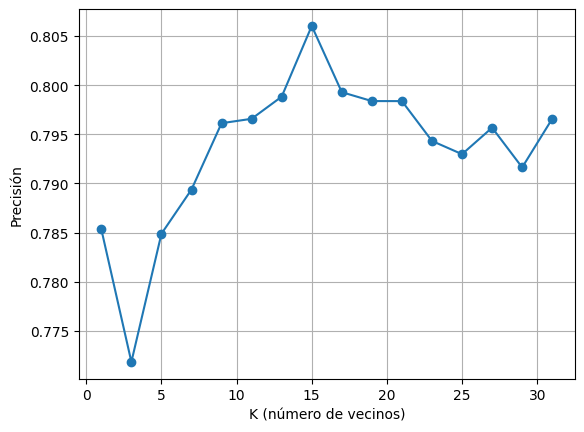

Mejor K: 15


In [12]:
from sklearn.neighbors import KNeighborsClassifier

valores_k = list(range(1, 32, 2))
resultados = []
for k in valores_k:
    knn = KNeighborsClassifier(n_neighbors=k)
    # validación cruzada: entrena y prueba 5 veces con partes distintas del entrenamiento
    resultados.append(cross_val_score(knn, X_tr_s, y_tr, cv=5).mean())

mejor_k = valores_k[int(np.argmax(resultados))]
plt.plot(valores_k, resultados, marker="o")
plt.xlabel("K (número de vecinos)"); plt.ylabel("Precisión"); plt.grid(); plt.show()
print("Mejor K:", mejor_k)

Precisión KNN en prueba: 82.2 %


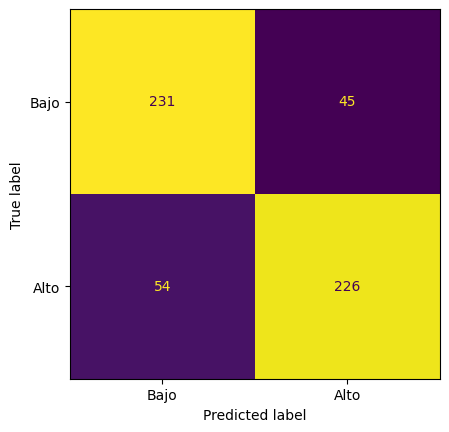

In [13]:
knn = KNeighborsClassifier(n_neighbors=mejor_k).fit(X_tr_s, y_tr)
pred_knn = knn.predict(X_te_s)
acc_knn = accuracy_score(y_te, pred_knn)
print("Precisión KNN en prueba:", round(acc_knn*100, 1), "%")

ConfusionMatrixDisplay(confusion_matrix(y_te, pred_knn), display_labels=["Bajo", "Alto"]).plot(colorbar=False)
plt.show()

**Conclusión 2:** el mejor K fue 15 y la precisión en prueba fue 82.2 %. La matriz de confusión (figura 6.2 del documento) muestra los aciertos en la diagonal; lo de fuera son errores (falsos positivos y falsos negativos). KNN es fácil de entender pero se vuelve lento con muchos datos, porque tiene que calcular la distancia contra todos los ejemplos cada vez que predice.

## Ejercicio 3. Árbol de decisión

**Idea en una frase:** el modelo aprende una serie de **preguntas de sí/no** ordenadas, como el juego de "20 preguntas", hasta llegar a una respuesta.

**Analogía:** un diagrama de flujo. Ejemplo: "¿Lectura crítica > 60? Si sí, ¿Ciencias > 55? ..." y al final dice "Alto" o "Bajo".

**Cómo funciona:**
1. Busca la pregunta que mejor separa las clases (por ejemplo, "lectura crítica ≤ 58").
2. Divide los datos en dos grupos y repite en cada grupo.
3. Se detiene cuando llega a la profundidad máxima o cuando el grupo ya es de una sola clase.

**Lo importante:** la **profundidad**. Un árbol muy profundo memoriza los datos de entrenamiento (overfitting, como en la figura 5.12 del capítulo anterior).

**Aplicación:** pruebo distintas profundidades y comparo la precisión en entrenamiento y en prueba para escoger la que no memoriza. Además dibujo el árbol para poder *leer* las reglas que aprendió.

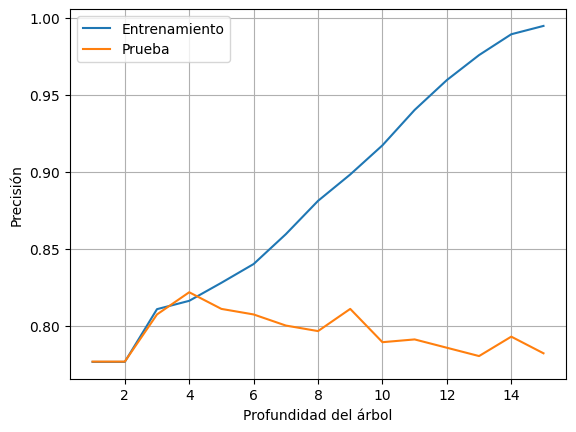

In [14]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

profundidades = range(1, 16)
acc_train, acc_test = [], []
for d in profundidades:
    arbol = DecisionTreeClassifier(max_depth=d, random_state=0).fit(X_tr, y_tr)
    acc_train.append(arbol.score(X_tr, y_tr))
    acc_test.append(arbol.score(X_te, y_te))

plt.plot(profundidades, acc_train, label="Entrenamiento")
plt.plot(profundidades, acc_test, label="Prueba")
plt.xlabel("Profundidad del árbol"); plt.ylabel("Precisión"); plt.legend(); plt.grid(); plt.show()

Cuando la precisión de entrenamiento sigue subiendo pero la de prueba baja o se estanca, el árbol está memorizando. Escojo la profundidad donde la prueba es mejor y luego dibujo el árbol.

Profundidad elegida: 4
Precisión árbol en prueba: 82.2 %


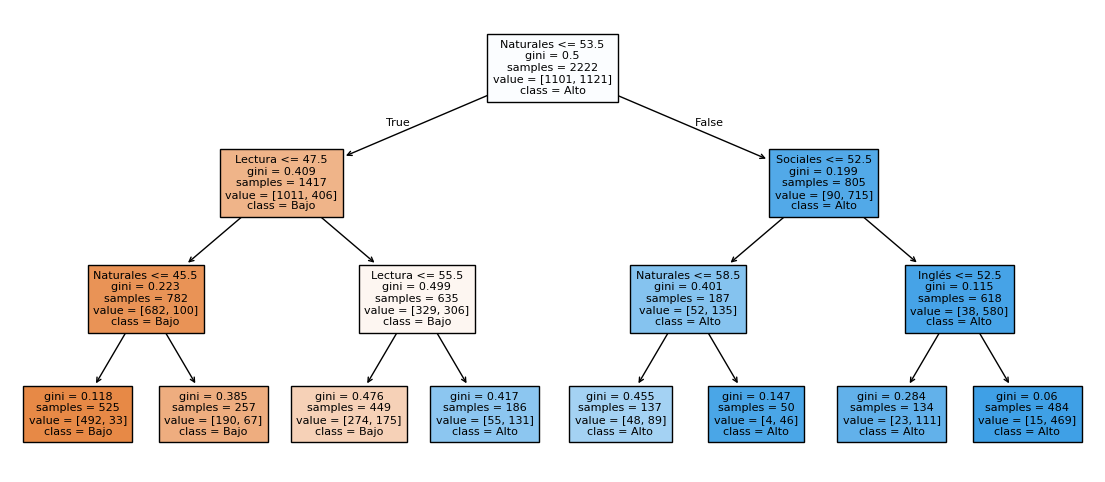

Importancia de cada característica:
  Lectura: 0.21
  Naturales: 0.73
  Sociales: 0.04
  Inglés: 0.02


In [15]:
mejor_prof = list(profundidades)[int(np.argmax(acc_test))]
arbol = DecisionTreeClassifier(max_depth=mejor_prof, random_state=0).fit(X_tr, y_tr)
pred_arbol = arbol.predict(X_te)
acc_arbol = accuracy_score(y_te, pred_arbol)
print("Profundidad elegida:", mejor_prof)
print("Precisión árbol en prueba:", round(acc_arbol*100, 1), "%")

# para dibujarlo uso un árbol pequeño (profundidad 3) y así se puede leer
arbol_pequeno = DecisionTreeClassifier(max_depth=3, random_state=0).fit(X_tr, y_tr)
plt.figure(figsize=(14, 6))
plot_tree(arbol_pequeno, feature_names=["Lectura", "Naturales", "Sociales", "Inglés"],
          class_names=["Bajo", "Alto"], filled=True, fontsize=8)
plt.show()

print("Importancia de cada característica:")
for nombre, imp in zip(["Lectura", "Naturales", "Sociales", "Inglés"], arbol.feature_importances_):
    print(f"  {nombre}: {imp:.2f}")

**Conclusión 3:** la profundidad elegida fue 4 y la precisión en prueba fue 82.2 %. Con árboles muy profundos la precisión de entrenamiento se acerca a 100% pero la de prueba no mejora: es overfitting. La ventaja del árbol es que **se puede explicar** (se leen las preguntas) y la característica más importante fue "Naturales".

## Ejercicio 4. SVM (Support Vector Machine, máquina de vectores de soporte)

**Idea en una frase:** busca la **mejor línea (o frontera)** que separa las dos clases, dejando el **mayor margen posible** entre ellas.

**Analogía:** hay que trazar una calle entre dos barrios (las clases). SVM busca la calle **más ancha** posible; las casas que quedan pegadas a los bordes de la calle son los **vectores de soporte** y son las únicas que importan para trazarla.

**Cómo funciona:**
1. Con datos de 2 características la frontera es una línea; con 4 características es un hiperplano.
2. Se escoge la frontera con mayor margen.
3. Si los datos no se pueden separar con una línea recta, se usa un **kernel** (por ejemplo `rbf`) que "curva" la frontera.
4. El parámetro **C** controla cuánto se permite equivocarse: C alto = frontera estricta, C bajo = más flexible.

**Aplicación:** comparo un kernel lineal contra uno `rbf` y pruebo varios valores de C.

In [16]:
from sklearn.svm import SVC

resultados_svm = []
for kernel in ["linear", "rbf"]:
    for C in [0.1, 1, 10]:
        svm = SVC(kernel=kernel, C=C).fit(X_tr_s, y_tr)
        resultados_svm.append((kernel, C, svm.score(X_te_s, y_te)))

tabla_svm = pd.DataFrame(resultados_svm, columns=["Kernel", "C", "Precisión en prueba"])
tabla_svm

,Kernel,C,Precisión en prueba
0,linear,0.1,0.830935
1,linear,1.0,0.834532
2,linear,10.0,0.834532
3,rbf,0.1,0.832734
4,rbf,1.0,0.829137
5,rbf,10.0,0.829137


Mejor combinación: linear con C = 1.0
Precisión SVM en prueba: 83.5 %
Vectores de soporte usados: 997 de 2222


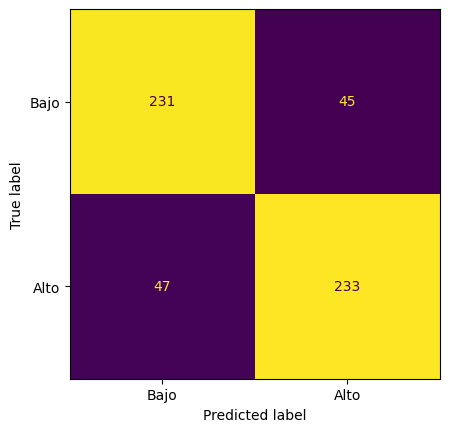

In [17]:
mejor = tabla_svm.loc[tabla_svm["Precisión en prueba"].idxmax()]
svm = SVC(kernel=mejor["Kernel"], C=mejor["C"]).fit(X_tr_s, y_tr)
pred_svm = svm.predict(X_te_s)
acc_svm = accuracy_score(y_te, pred_svm)

print("Mejor combinación:", mejor["Kernel"], "con C =", mejor["C"])
print("Precisión SVM en prueba:", round(acc_svm*100, 1), "%")
print("Vectores de soporte usados:", len(svm.support_vectors_), "de", len(X_tr_s))

ConfusionMatrixDisplay(confusion_matrix(y_te, pred_svm), display_labels=["Bajo", "Alto"]).plot(colorbar=False)
plt.show()

**Conclusión 4:** la mejor combinación fue linear con C = 1.0 y la precisión fue 83.5 %. Solo una parte de los datos (los vectores de soporte) define la frontera. SVM suele funcionar muy bien con pocos datos y pocas características, pero se vuelve lento con muchísimos datos.

## Comparación final de los tres algoritmos

In [18]:
comparacion = pd.DataFrame({
    "Algoritmo": ["KNN", "Árbol de decisión", "SVM"],
    "Precisión en prueba (%)": [round(acc_knn*100, 1), round(acc_arbol*100, 1), round(acc_svm*100, 1)]
})
comparacion

,Algoritmo,Precisión en prueba (%)
0,KNN,82.2
1,Árbol de decisión,82.2
2,SVM,83.5


## Conclusión general
1. **ML vs. programación tradicional:** cuando la regla es conocida y simple (multiplicar matrices) es mejor programarla; cuando no se conoce (predecir el desempeño en matemáticas a partir de otras materias) ML aprende la regla desde los datos.
2. Con los mismos datos, los tres algoritmos dieron precisiones parecidas (82.2 %, 82.2 % y 83.5 %). Como dice el documento en la sección 6.7 (*la irrazonable efectividad de los datos*), muchas veces importan más los **datos** que el algoritmo.
3. Cada uno tiene su fortaleza: **KNN** es el más fácil de entender, el **árbol** es el más fácil de explicar y **SVM** suele ser el más preciso con pocos datos.
4. **Sesgo (sección 6.11):** este modelo solo predice a partir de puntajes; no explica por qué un estudiante rinde más o menos (correlación no es causa), y si los datos no representan a todos los estudiantes del país, las predicciones pueden ser injustas para algunos grupos.